# Indicateurs de risque de trois ETF STOXX Europe 600

Le notebook 04 comparait la performance de trois ETF répliquant le même indice.
Celui-ci mesure le risque associé : distribution des rendements journaliers,
volatilité et rendement annualisés, maximum drawdown.

Données : MEUD.PA (Amundi), ETZ.PA (BNP Paribas Easy), EXSA.DE (iShares),
660 séances communes du 19 février 2024 au 25 septembre 2026, cours de clôture
ajustés téléchargés via yfinance et figés dans `data/etf_europe.csv`.

Auteur : KOULEKPOTO Yao Eloge Crédo — octobre 2026

## 1. Données

In [1]:
import pandas as pd
etf_eur = pd.read_csv("data/etf_europe.csv", index_col= ["Date"], parse_dates=True)
etf_eur

,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2023-01-02,12.854000,38.388416,NaN
2023-01-03,12.916000,38.586517,NaN
2023-01-04,13.108000,39.198860,NaN
2023-01-05,13.084000,39.086304,NaN
2023-01-06,13.246000,39.581573,NaN
...,...,...,...
2026-09-22,21.190001,63.580002,316.950012
2026-09-23,21.100000,63.360001,315.850006
2026-09-24,20.990000,62.980000,314.049988


In [2]:
etf_eur = etf_eur.dropna()
etf_eur

,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2024-02-19,15.112000,45.084953,223.820007
2024-02-20,15.094000,45.010891,223.429993
2024-02-21,15.066000,44.936844,223.139999
2024-02-22,15.198000,45.353394,225.250000
2024-02-23,15.258000,45.501503,226.190002
...,...,...,...
2026-09-21,21.174999,63.509998,316.600006
2026-09-22,21.190001,63.580002,316.950012
2026-09-23,21.100000,63.360001,315.850006


## 2. Performance cumulée, base 100

In [3]:
etf_base100 = (etf_eur/etf_eur.iloc[0])*100
etf_base100 = etf_base100.rename(columns={"ETZ.PA":"BNP Paribas Easy", "EXSA.DE":"iShares", "MEUD.PA":"Amundi"})
etf_base100

,BNP Paribas Easy,iShares,Amundi
Date,,,
2024-02-19,100.000000,100.000000,100.000000
2024-02-20,99.880885,99.835727,99.825746
2024-02-21,99.695603,99.671488,99.696181
2024-02-22,100.569081,100.595410,100.638903
2024-02-23,100.966119,100.923922,101.058884
...,...,...,...
2026-09-21,140.120425,140.867393,141.452951
2026-09-22,140.219692,141.022663,141.609330
2026-09-23,139.624138,140.534693,141.117861


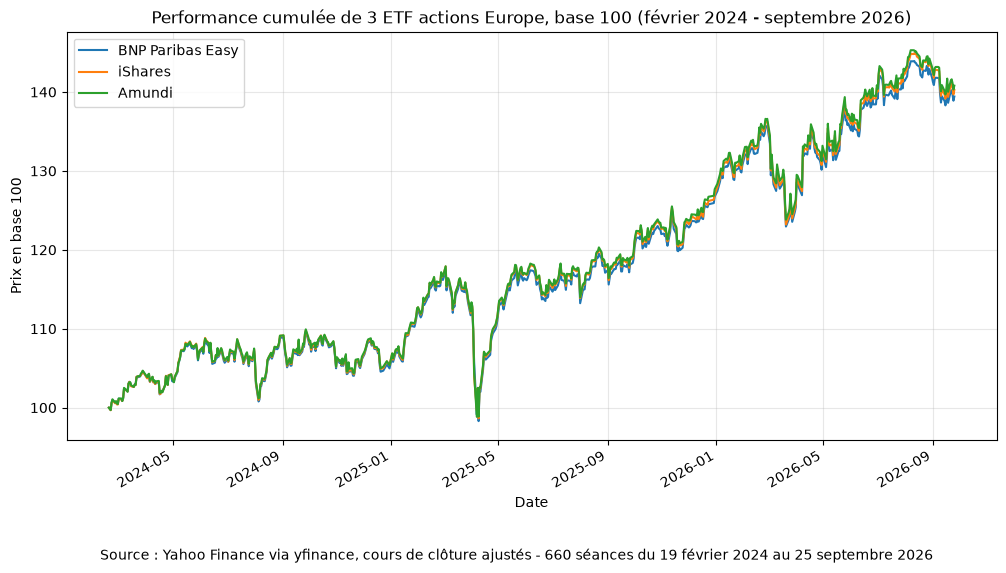

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,6))
etf_base100.plot(ax=ax)
ax.set_title("Performance cumulée de 3 ETF actions Europe, base 100 (février 2024 - septembre 2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Prix en base 100")
ax.grid(alpha=0.3)
fig.text(0.5,0,"Source : Yahoo Finance via yfinance, cours de clôture ajustés - 660 séances du 19 février 2024 au 25 septembre 2026", ha="center")
fig.savefig("images/base100.png", dpi=150, bbox_inches="tight")

## 3. Distribution des rendements journaliers

In [5]:
etf_returns = etf_eur.pct_change()
etf_returns = etf_returns.dropna()
etf_returns

,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2024-02-20,-0.001191,-0.001643,-0.001743
2024-02-21,-0.001855,-0.001645,-0.001298
2024-02-22,0.008761,0.009270,0.009456
2024-02-23,0.003948,0.003266,0.004173
2024-02-26,-0.002884,-0.003662,-0.004156
...,...,...,...
2026-09-21,0.010740,0.010662,0.010211
2026-09-22,0.000708,0.001102,0.001106
2026-09-23,-0.004247,-0.003460,-0.003471


In [6]:
etf_returns.describe()

,ETZ.PA,EXSA.DE,MEUD.PA
count,659.000000,659.000000,659.000000
mean,0.000539,0.000548,0.000554
std,0.008267,0.008265,0.008351
min,-0.062469,-0.052576,-0.052715
25%,-0.003782,-0.003763,-0.003742
50%,0.000542,0.000490,0.000519
75%,0.005402,0.005315,0.005385
max,0.040355,0.040416,0.040513


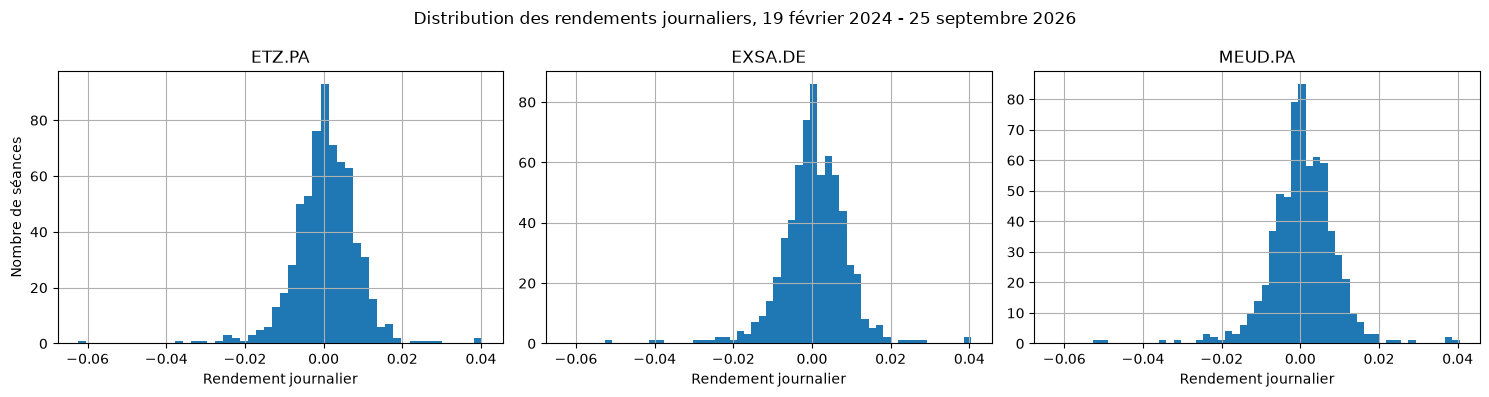

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharex=True)
for col, ax in zip(etf_returns.columns, axes):
    etf_returns[col].hist(bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Rendement journalier")

axes[0].set_ylabel("Nombre de séances")
fig.suptitle("Distribution des rendements journaliers, 19 février 2024 - 25 septembre 2026")
fig.tight_layout()


Les trois distributions sont presque identiques, ce qui est attendu pour trois fonds suivant le même indice. Elles sont centrées sur une valeur très légèrement positive, autour de +0,05 % par jour, soit le rendement moyen de la période.

La masse des séances se concentre entre −1 % et +1 %. La moitié des journées tient même dans un intervalle plus resserré, de −0,38 % à +0,54 % pour ETZ.PA.

Aux extrémités, quelques séances sont très éloignées du centre : jusqu'à −6,25 % pour ETZ.PA et +4,04 % en hausse. Leurs barres sont à peine visibles, mais ces journées existent et pèsent lourd dans la performance.

C'est le point à retenir. Avec un écart-type journalier de 0,83 %, une baisse de 6 % représente plus de sept écarts-types. Sous une loi normale, un tel événement serait pratiquement impossible — il s'est pourtant produit sur une fenêtre de 660 séances. Les queues de distribution des rendements financiers sont plus épaisses que ne le prévoit ce modèle, et une mesure de risque fondée sur le seul écart-type sous-estime les chocs réellement subis. D'où l'intérêt du maximum drawdown, qui mesure la perte constatée et non celle qu'un modèle prédit.

## 4. Rendement et risque annualisés

In [8]:
#Volatilité annualisée
volat_annualisee = etf_returns.std()*252**0.5
volat_annualisee

ETZ.PA     0.131232
EXSA.DE    0.131209
MEUD.PA    0.132569
dtype: float64

In [9]:
#rendement annualisé
performance = etf_eur.iloc[-1]/etf_eur.iloc[0]
n_years = (etf_base100.index[-1] - etf_base100.index[0]).days/365.25
taux_annualise = performance**(1/n_years) - 1
taux_annualise

ETZ.PA     0.136461
EXSA.DE    0.139031
MEUD.PA    0.140775
dtype: float64

In [10]:
recap = pd.DataFrame([performance-1, taux_annualise, volat_annualisee])
recap = recap.rename(index={0:"Performance globale",1:"Rendement annualisé",2:"Volatilité annualisée"})
recap = recap.T
recap.style.format("{:.2%}")

,Performance globale,Rendement annualisé,Volatilité annualisée
ETZ.PA,39.43%,13.65%,13.12%
EXSA.DE,40.25%,13.90%,13.12%
MEUD.PA,40.81%,14.08%,13.26%



| | Performance globale | Rendement annualisé | Volatilité annualisée |
|---|---|---|---|
| ETZ.PA | 39,43 % | 13,65 % | 13,12 % |
| EXSA.DE | 40,25 % | 13,90 % | 13,12 % |
| MEUD.PA | 40,81 % | 14,08 % | 13,26 % |

Les trois volatilités tiennent dans 0,14 point d'écart, à 13,1-13,3 % par an. Le résultat est attendu : trois fonds qui répliquent le même indice portent le même risque de marché, et la gestion n'a aucune latitude pour s'en écarter.

Le choix entre eux ne se joue donc pas sur le couple rendement-risque mais sur le seul rendement, et l'ordre de classement est le même que celui des frais. MEUD.PA, le moins cher des trois à 0,07 % par an, arrive en tête.

C'est ce qui rend la décision immédiate ici, et presque jamais ailleurs. Entre deux fonds suivant des indices différents ou gérés activement, un rendement plus élevé s'accompagne généralement d'une volatilité plus forte, et il faut arbitrer entre les deux. Ici le risque est identique par construction, ce qui isole complètement l'effet des frais et de la qualité de réplication.

Le niveau de volatilité lui-même, autour de 13 %, correspond à ce qu'on attend d'un indice actions développées large.

## 5. Maximum drawdown

In [11]:
#Max drawdown
etf_tickerb100 = (etf_eur/etf_eur.iloc[0])*100
max_glissant = etf_tickerb100.cummax()
max_glissant.tail()

,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2026-09-21,143.925353,144.909792,145.295327
2026-09-22,143.925353,144.909792,145.295327
2026-09-23,143.925353,144.909792,145.295327
2026-09-24,143.925353,144.909792,145.295327
2026-09-25,143.925353,144.909792,145.295327


In [12]:
drawdown = (etf_tickerb100 - max_glissant)/max_glissant
drawdown

,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2024-02-19,0.000000,0.000000,0.000000
2024-02-20,-0.001191,-0.001643,-0.001743
2024-02-21,-0.003044,-0.003285,-0.003038
2024-02-22,0.000000,0.000000,0.000000
2024-02-23,0.000000,0.000000,0.000000
...,...,...,...
2026-09-21,-0.026437,-0.027896,-0.026445
2026-09-22,-0.025747,-0.026824,-0.025369
2026-09-23,-0.029885,-0.030192,-0.028752


In [13]:
max_dd = drawdown.min()
max_dd

ETZ.PA    -0.162778
EXSA.DE   -0.163286
MEUD.PA   -0.161798
dtype: float64

In [14]:
date_creux = drawdown.idxmin()
date_creux

ETZ.PA    2025-04-09
EXSA.DE   2025-04-09
MEUD.PA   2025-04-07
dtype: datetime64[us]

In [15]:
dd_recap = pd.DataFrame({"Max drawdown": max_dd, "Date du creux": date_creux})
dd_recap.style.format({"Max drawdown": "{:.2%}", "Date du creux":"{:%d/%m/%Y}"})

,Max drawdown,Date du creux
ETZ.PA,-16.28%,09/04/2025
EXSA.DE,-16.33%,09/04/2025
MEUD.PA,-16.18%,07/04/2025


In [16]:
etf_returns.idxmin()

ETZ.PA    2025-04-07
EXSA.DE   2025-04-04
MEUD.PA   2025-04-07
dtype: datetime64[us]

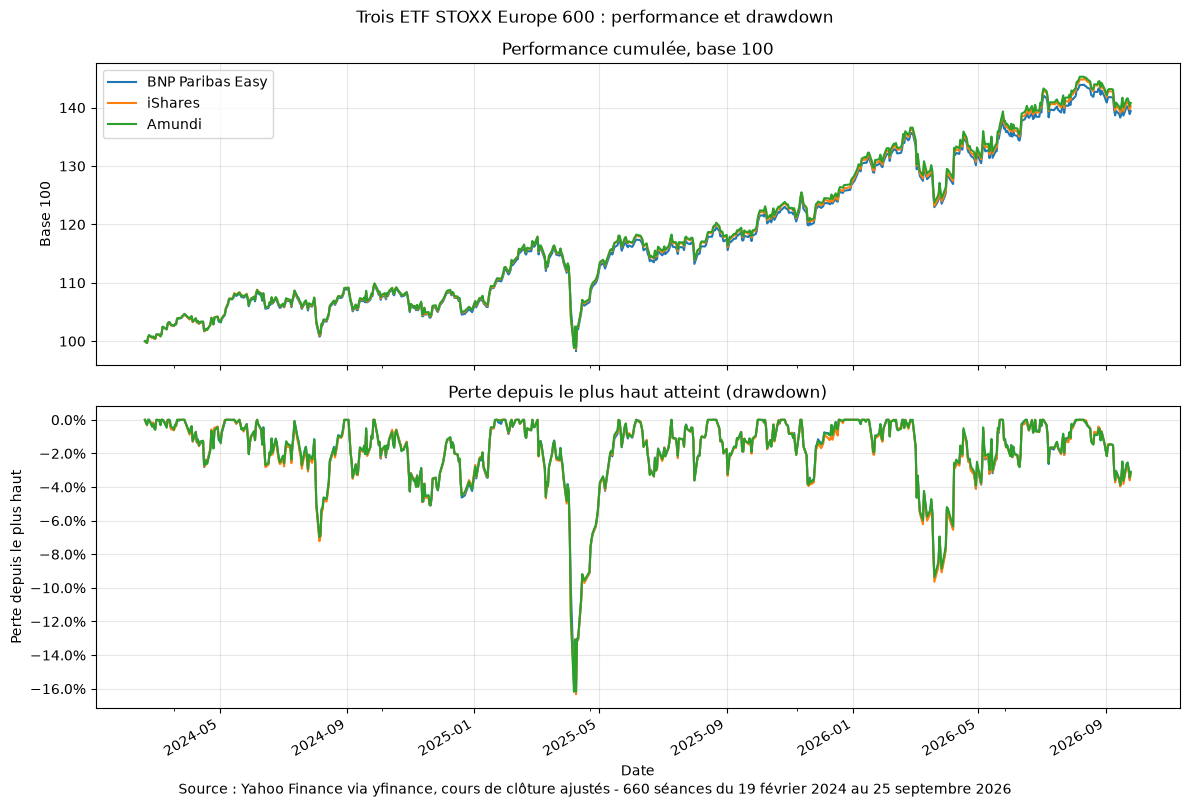

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
etf_base100.plot(ax=axes[0])
drawdown.plot(ax=axes[1])
axes[0].set_title("Performance cumulée, base 100")
axes[1].set_title("Perte depuis le plus haut atteint (drawdown)")
axes[0].set_ylabel("Base 100")
axes[1].set_ylabel("Perte depuis le plus haut")
axes[1].set_xlabel("Date")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
axes[1].legend().remove()
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
fig.suptitle("Trois ETF STOXX Europe 600 : performance et drawdown")
fig.text(0.5, 0, "Source : Yahoo Finance via yfinance, cours de clôture ajustés - 660 séances du 19 février 2024 au 25 septembre 2026", ha="center")
fig.tight_layout()
fig.savefig("images/drawdown.png", dpi=150, bbox_inches="tight")



| | Max drawdown | Date du creux |
|---|---|---|
| ETZ.PA | -16,28 % | 09/04/2025 |
| EXSA.DE | -16,33 % | 09/04/2025 |
| MEUD.PA | -16,18 % | 07/04/2025 |

Le drawdown mesure, à chaque date, l'écart entre la valeur du fonds et le plus haut qu'il avait atteint jusque-là. Le maximum drawdown est la pire de ces pertes sur toute la période : ce qu'aurait subi un investisseur entré au plus mauvais moment et sorti au creux.

Les trois fonds perdent entre 16,18 % et 16,33 %, soit 0,15 point d'écart. Les creux tombent les 7 et 9 avril 2025, séparés par un rebond de trois points entre les deux dates. Ces chiffres quasi identiques confirment l'alignement correct des trois séries.

Le creux coïncide avec les pires séances journalières des trois ETF, les 4 et 7 avril 2025. Le choc d'avril 2025 apparaît ainsi dans les trois mesures de ce notebook : une queue de distribution dans l'histogramme, un trou dans la courbe base 100, un creux dans celle du drawdown.

Un détail mérite d'être relevé. Le 4 avril, ETZ.PA affiche −9,95 % de drawdown quand les deux autres sont déjà à −11,5 % et −11,9 %. L'écart se referme dès le lendemain. Les jours de forte tension, les cours de clôture de fonds répliquant le même indice peuvent diverger de près de deux points, le temps que la liquidité revienne. C'est dans ces moments que la qualité de réplication se mesure, pas en régime normal.

Ce que cette mesure ajoute à la volatilité : avec un écart-type annualisé de 13,2 %, une perte de 16 % représente plus d'un écart-type complet sur l'année, concentré en quelques séances. La volatilité décrit l'amplitude habituelle des variations ; le drawdown dit ce qui s'est réellement produit au pire moment. Un investisseur subit le second, pas le premier.